# Long Short-Term Memory (LSTM) for Predicting Pore Pressure in Liquefaction

**Learning Objectives:**
- Understand why standard models fail to capture stress history-dependent behavior
- Learn how LSTM networks capture sequential dependencies in time-series data
- Master time-window sampling for sequence-to-sequence prediction
- Compare constitutive models vs data-driven LSTM approaches

**Reference Paper:** Choi and Kumar (2023). "A Machine Learning Approach to Predicting Pore Pressure Response in Liquefiable Sands under Cyclic Loading." Geo-Congress 2023.

**Exercise:** [![Open in Colab](https://img.shields.io/badge/Open%20in-Colab-F9AB00?style=flat-square&logo=googlecolab)](https://colab.research.google.com/github/kks32-courses/ai-geotech/blob/main/docs/05-lstm/05a-lstm-liquefaction-exercise.ipynb)
**Solution:** [![Open in Colab](https://img.shields.io/badge/Open%20in-Colab-F9AB00?style=flat-square&logo=googlecolab)](https://colab.research.google.com/github/kks32-courses/ai-geotech/blob/main/docs/05-lstm/05a-lstm-liquefaction.ipynb)

**Reference:** [lstm-liquefaction](https://arxiv.org/pdf/2206.07780)

## The Problem: Liquefaction and the Shielding Effect

### What is Liquefaction?

During an earthquake, saturated soils experience cyclic loading that can cause **liquefaction** - a phenomenon where:
- Excess pore water pressure builds up
- Effective stress decreases
- Soil loses strength and stiffness
- When excess pore pressure equals the confining pressure ($r_u = 1.0$), liquefaction occurs

### The Shielding Effect

**Critical Observation:** Pore pressure generation depends on **stress history**, not just current stress!

**Shielding Effect:** Excess pore pressure does NOT increase when the current shear stress amplitude is lower than the peak prior amplitude.

- ✅ **New peak stress** > prior peak → pore pressure increases rapidly
- ❌ **Current stress** < prior peak → pore pressure remains nearly constant (shielded)

### Why Traditional Models Fail

Sophisticated constitutive models like **PM4Sand** and **PDMY02** fail to capture the shielding effect:
- They predict continuous pore pressure increase even when shielding should occur
- They miss the fluctuations in pore pressure response
- They provide less accurate predictions of time to liquefaction

**Our Solution:** Use LSTM networks to learn the stress history-dependent behavior directly from experimental data!

## Get data

In [1]:
# Fetch the data. -nc keeps an existing local copy, so a re-run does not create
# "data.zip.1", and -o overwrites the extracted files without prompting.
import os

if not os.path.exists('data.zip'):
    !wget -nc https://github.com/kks32-courses/ai-geotech/raw/refs/heads/main/docs/05-lstm/data.zip
else:
    print("Using the local copy of data.zip")
!unzip -o -q data.zip -x '__MACOSX/*'


Using the local copy of data.zip


## Import Libraries

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
from pathlib import Path
from tqdm.auto import tqdm

# Deep learning libraries - PyTorch
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, TensorDataset

# Evaluation
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Set random seeds for reproducibility
np.random.seed(42)
torch.manual_seed(42)

# Set device - prioritize MPS (Apple Silicon), then CUDA, then CPU
if torch.backends.mps.is_available():
    device = torch.device('mps')
    print("🚀 Using Apple Silicon GPU (MPS) for acceleration!")
elif torch.cuda.is_available():
    device = torch.device('cuda')
    print("🚀 Using NVIDIA GPU (CUDA)")
else:
    device = torch.device('cpu')
    print("⚠️  Using CPU (this will be slow)")

print(f"Device: {device}")
print(f"PyTorch version: {torch.__version__}")

🚀 Using Apple Silicon GPU (MPS) for acceleration!
Device: mps
PyTorch version: 2.14.0


## Understanding the Experimental Data

### Cyclic Simple Shear Tests on Nevada Sand

**Data Source:** Kwan et al. (2017) - Cyclic simple shear tests on saturated Nevada sand

**Test Conditions:**
- **Loose samples:** $D_r$ = 33-55% (Experiment 9, transient loading)
- **Dense samples:** $D_r$ = 72-94% (Experiment 8, modulated sine loading)
- **Loading types:**
  - Harmonic (constant amplitude)
  - Modulated-up (increasing amplitude)
  - Modulated-down (decreasing amplitude)

**Measured Variables:**
- Time [sec]
- Shear Strain [%]
- Shear Stress [kPa]
- Effective Vertical Stress [kPa]
- Excess Pore Pressure [kPa]

**Computed Variables:**
- Relative Density $D_r$ [%], read from line 2 of the CSV header. The header gives the
  range for the whole experiment series and not a per-trial value, so we take the
  midpoint: 83% for Experiment 8 and 44% for Experiment 9. The third input channel
  therefore separates the dense series from the loose one; it does not resolve
  differences between trials within a series.
- Pore pressure ratio: $r_u = \frac{\text{Excess Pore Pressure}}{\text{Confining Pressure}}$


## Data Loading Functions

Let's create functions to load and process the cyclic simple shear test data:

In [3]:
import re


def augment_data(df, add_length=900, time_step=None):
    """
    Augment data by adding static state before cyclic loading begins.
    This represents the initial state before shearing starts.

    time_step defaults to the median sampling interval of the record itself, so
    the concatenated time vector has no step discontinuity at the join.
    """
    if time_step is None:
        time_step = float(np.median(np.diff(df["Time [sec]"].to_numpy())))
    css_start_time = time_step * add_length
    add_Dr = np.full((add_length, 1), df["Dr [%]"].iloc[0])
    add_Time = np.reshape(np.linspace(0, css_start_time, add_length), (add_length, 1))
    add_ShearStrain = np.full((add_length, 1), 0)
    add_SheerStress = np.full((add_length, 1), 0)
    add_ConfPressure = np.full((add_length, 1), df["Effective Vertical Stress [kPa]"].iloc[0])
    add_ru = np.full((add_length, 1), df["ru"].iloc[0])
    add_PWP = np.full((add_length, 1), df["Excess Pore Pressure [kPa]"].iloc[0])

    # Aggregate as array
    add_data = np.hstack(
        (add_Dr, add_Time, add_ShearStrain, add_SheerStress, add_ConfPressure, add_ru, add_PWP)
    )

    # Append original timesteps
    first_timesteps = add_Time
    last_timesteps = first_timesteps[-1, 0] + df["Time [sec]"].to_numpy()
    last_timesteps = np.reshape(last_timesteps, (last_timesteps.shape[0], 1))
    full_timesteps = np.vstack((first_timesteps, last_timesteps))

    # Create dataframe
    header = df.columns
    df_add_data = pd.DataFrame(add_data, columns=header)

    # Append
    df_augmented = pd.concat([df_add_data, df], ignore_index=True)
    df_augmented["Time [sec]"] = full_timesteps

    return df_augmented


DR_RANGE = re.compile(r"(\d+(?:\.\d+)?)\s*to\s*(\d+(?:\.\d+)?)\s*%\s*Relative Density",
                      re.IGNORECASE)


def read_relative_density(file_path):
    """
    Read the relative density from line 2 of the CSV header.

    Line 2 reads, for example,
        Exp8: 72 to 94% Relative Density Cyclic Simple Shear Tests under Modulated Sine Loadings
    The header states the range for the experiment series, not a per-trial value, so
    this returns the midpoint: 83% for Experiment 8 and 44% for Experiment 9. All 57
    CSVs in Experiment-8/ and Experiment-9/ carry this line.

    Raises ValueError if the line does not match, rather than falling back to a
    default that would make the channel a constant.
    """
    with open(file_path) as f:
        header_line = f.readlines()[1]
    match = DR_RANGE.search(header_line)
    if match is None:
        raise ValueError(
            f"No relative density range on line 2 of {file_path}: {header_line!r}"
        )
    low, high = float(match.group(1)), float(match.group(2))
    return 0.5 * (low + high)


def csv_to_dataframe(file_path, num_headers=5):
    """
    Convert CSV file to dataframe with computed ru value.

    Args:
        file_path: Path to CSV file
        num_headers: Number of header rows (default=5)

    Returns:
        DataFrame with added Dr and ru columns
    """
    relative_density = read_relative_density(file_path)

    # Read CSV
    df = pd.read_csv(file_path, header=num_headers)

    # Add relative density as first column, in percent
    df.insert(loc=0, column="Dr [%]", value=relative_density)

    # Compute and insert ru (pore pressure ratio)
    confining_pressure = df['Effective Vertical Stress [kPa]'].iloc[0]
    ru = df['Excess Pore Pressure [kPa]'] / confining_pressure
    df.insert(loc=5, column="ru", value=ru)

    # Augment data
    df = augment_data(df=df)

    return df


## Load Sample Data

Let's load a sample dataset to visualize the cyclic simple shear test results:

In [4]:
# Load a sample dataset
sample_file = "Experiment-9/Trial-1_121227_yc1.csv"
sample_df = csv_to_dataframe(sample_file)

print(f"Dataset shape: {sample_df.shape}")
print(f"\nColumns: {list(sample_df.columns)}")
print(f"\nRelative Density: {sample_df['Dr [%]'].iloc[0]:.1f}%")
print(f"\nFirst few rows:")
sample_df.head()

Dataset shape: (9565, 7)

Columns: ['Dr [%]', 'Time [sec]', 'Shear Strain [%]', 'Shear Stress [kPa]', 'Effective Vertical Stress [kPa]', 'ru', 'Excess Pore Pressure [kPa]']

Relative Density: 44.0%

First few rows:


,Dr [%],Time [sec],Shear Strain [%],Shear Stress [kPa],Effective Vertical Stress [kPa],ru,Excess Pore Pressure [kPa]
0,44.0,0.000000,0.0,0.0,104.523318,0.0,0.0
1,44.0,0.013014,0.0,0.0,104.523318,0.0,0.0
2,44.0,0.026029,0.0,0.0,104.523318,0.0,0.0
3,44.0,0.039043,0.0,0.0,104.523318,0.0,0.0
4,44.0,0.052058,0.0,0.0,104.523318,0.0,0.0


## Visualize Cyclic Simple Shear Test Data

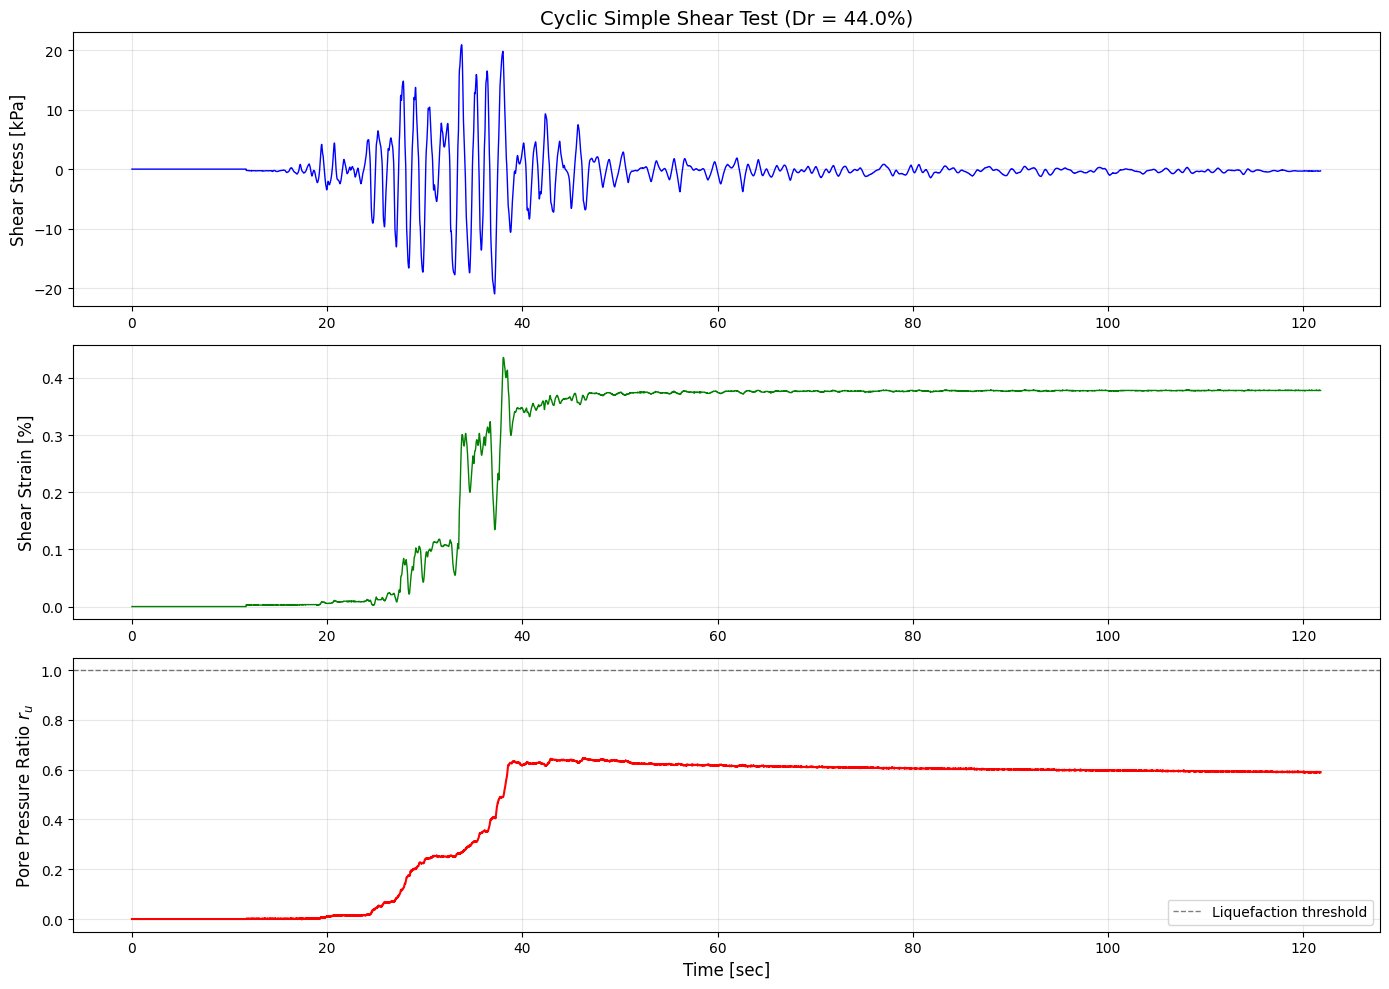

Maximum pore pressure ratio: 0.647
Liquefaction did not occur


In [5]:
# Plot the cyclic simple shear test results
fig, axes = plt.subplots(3, 1, figsize=(14, 10))

# Plot 1: Shear Stress vs Time
ax = axes[0]
ax.plot(sample_df["Time [sec]"], sample_df["Shear Stress [kPa]"], 'b-', linewidth=1)
ax.set_ylabel('Shear Stress [kPa]', fontsize=12)
ax.set_title(f'Cyclic Simple Shear Test (Dr = {sample_df["Dr [%]"].iloc[0]:.1f}%)', fontsize=14)
ax.grid(True, alpha=0.3)

# Plot 2: Shear Strain vs Time
ax = axes[1]
ax.plot(sample_df["Time [sec]"], sample_df["Shear Strain [%]"], 'g-', linewidth=1)
ax.set_ylabel('Shear Strain [%]', fontsize=12)
ax.grid(True, alpha=0.3)

# Plot 3: Pore Pressure Ratio vs Time
ax = axes[2]
ax.plot(sample_df["Time [sec]"], sample_df["ru"], 'r-', linewidth=1.5)
ax.axhline(y=1.0, color='k', linestyle='--', linewidth=1, alpha=0.5, label='Liquefaction threshold')
ax.set_xlabel('Time [sec]', fontsize=12)
ax.set_ylabel('Pore Pressure Ratio $r_u$', fontsize=12)
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Maximum pore pressure ratio: {sample_df['ru'].max():.3f}")
print(f"Liquefaction {'occurred' if sample_df['ru'].max() >= 1.0 else 'did not occur'}")

## What is an LSTM Network?

### From RNN to LSTM

**Recurrent Neural Networks (RNN):**
- Process sequential data by maintaining a "memory" of previous inputs
- **Problem:** Vanishing/exploding gradients for long sequences
- Cannot learn long-term dependencies effectively

**Long Short-Term Memory (LSTM):**
- Greatly reduces the vanishing gradient problem: the additive cell-state path lets
  gradients flow across many steps, though they still decay whenever the forget gate
  sits below 1
- Uses **gates** to control information flow
- Can learn both short-term and long-term patterns

### LSTM Cell Architecture

An LSTM cell has three gates:

1. **Forget Gate** ($f_t$): What information to discard from previous cell state
   $$f_t = \sigma(W_{xf}x_t + W_{hf}h_{t-1} + b_f)$$

2. **Input Gate** ($i_t$): What new information to add to cell state
   $$i_t = \sigma(W_{xi}x_t + W_{hi}h_{t-1} + b_i)$$
   $$\tilde{C}_t = \tanh(W_{xc}x_t + W_{hc}h_{t-1} + b_c)$$

3. **Output Gate** ($o_t$): What information to output
   $$o_t = \sigma(W_{xo}x_t + W_{ho}h_{t-1} + b_o)$$

**Cell State Update:**
$$C_t = f_t \odot C_{t-1} + i_t \odot \tilde{C}_t$$
$$h_t = o_t \odot \tanh(C_t)$$

Where:
- $x_t$: Input at time $t$
- $h_t$: Hidden state (output)
- $C_t$: Cell state (memory)
- $\sigma$: Sigmoid function (outputs 0-1)
- $\odot$: Element-wise multiplication

### Why LSTM for Liquefaction?

**Perfect for the Shielding Effect:**
- **Forget gate** can forget low-stress periods
- **Input gate** selectively remembers peak stresses
- **Cell state** maintains long-term memory of stress history
- No need to hard-code "if current < peak" logic!

## Data Preparation for LSTM

### Time-Window Sampling

**Key Insight:** To predict $r_u$ at time $t+800$, we need the stress history from $t$ to $t+799$

**Features** ($\mathbf{X}_t \in \mathbb{R}^{3 \times 800}$):
- Normalized time: $[T_t, T_{t+1}, ..., T_{t+799}]$
- Shear stress history: $[\tau_t, \tau_{t+1}, ..., \tau_{t+799}]$
- Relative density (constant): $[D_r, D_r, ..., D_r]$

**Target** ($\mathbf{Y}_t \in \mathbb{R}^{1 \times 1}$):
- Pore pressure ratio at next time step: $r_{u,t+800}$

**Window Length:** 800 time steps. The median sampling interval is 0.013 s, so the
window spans 10.4 s. The Experiment-8 modulated-sine records have a dominant loading
frequency near 0.20 Hz, so the window covers about two cycles. The Experiment-9
transient records run from about 0.4 to 1.0 Hz, so the same window covers roughly four
to ten cycles.

In [6]:
# Time is divided by this fixed constant, the same for every trial. The longest
# record in the dataset lasts 515 s, so normalized time stays inside [0, 1].
TIME_REFERENCE_SEC = 600.0


def normalize_data(dfs):
    """
    Normalize shear stress by the confining pressure and time by a fixed constant.

    Dividing time by the trial's own final time would put the fraction of the whole
    test elapsed into every window. That leaks the total test duration, which
    correlates with when liquefaction occurs, so we divide by TIME_REFERENCE_SEC
    instead.
    """
    normalized_dfs = []
    for df in dfs:
        confining_pressure = df["Effective Vertical Stress [kPa]"].iloc[0]
        normalized_df = df.copy()
        normalized_df["Shear Stress [kPa]"] = df["Shear Stress [kPa]"] / confining_pressure
        normalized_df["Time [sec]"] = df["Time [sec]"] / TIME_REFERENCE_SEC
        # Normalize Dr to [0, 1]
        normalized_df["Dr [%]"] = df["Dr [%]"] / 100.0
        normalized_dfs.append(normalized_df)
    return normalized_dfs


def create_lstm_inputs(dfs, features, targets, window_length):
    """
    Create time-window sampled inputs for LSTM.

    Args:
        dfs: List of dataframes
        features: List of feature column names
        targets: List of target column names
        window_length: Length of time window (e.g., 800)

    Returns:
        Dictionary with feature datasets, target datasets, and windowed samples
    """
    feature_datasets = []
    target_datasets = []
    x_rnns = []
    y_rnns = []

    for df in dfs:
        # Extract features and targets as arrays
        feature_dataset = df[features].to_numpy()
        target_dataset = df[targets].to_numpy()

        feature_datasets.append(feature_dataset)
        target_datasets.append(target_dataset)

        datapoint = len(df)

        # Create sliding windows
        sampled_features = []
        sampled_targets = []

        for i in range(datapoint - window_length):
            # Window of features from t to t+window_length
            sampled_feature = feature_dataset[i:i+window_length, :]
            # Target at t+window_length
            sampled_target = target_dataset[i+window_length, :]
            sampled_features.append(sampled_feature)
            sampled_targets.append(sampled_target)

        x_rnn = np.asarray(sampled_features)  # Shape: (samples, window_length, features)
        y_rnn = np.asarray(sampled_targets)   # Shape: (samples, targets)

        x_rnns.append(x_rnn)
        y_rnns.append(y_rnn)

    return {
        "feature_datasets": feature_datasets,
        "target_datasets": target_datasets,
        "x_rnns": x_rnns,
        "y_rnns": y_rnns
    }

## Demonstrate Time-Window Sampling

Let's visualize how time-window sampling works:

Number of windows created: 8765
Shape of each window (features): (8765, 800, 3)
  - Samples: 8765
  - Window length: 800
  - Features: 3

Shape of targets: (8765, 1)


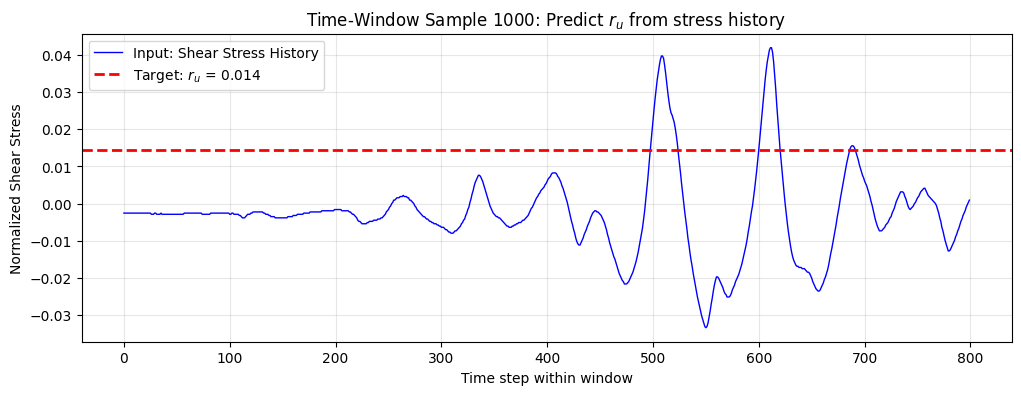

In [7]:
# Create a simple example
window_length = 800
features = ["Time [sec]", "Dr [%]", "Shear Stress [kPa]"]
targets = ["ru"]

# Normalize the sample dataframe
normalized_sample = normalize_data([sample_df])

# Create LSTM inputs
lstm_data = create_lstm_inputs(normalized_sample, features, targets, window_length)

print(f"Number of windows created: {len(lstm_data['x_rnns'][0])}")
print(f"Shape of each window (features): {lstm_data['x_rnns'][0].shape}")
print(f"  - Samples: {lstm_data['x_rnns'][0].shape[0]}")
print(f"  - Window length: {lstm_data['x_rnns'][0].shape[1]}")
print(f"  - Features: {lstm_data['x_rnns'][0].shape[2]}")
print(f"\nShape of targets: {lstm_data['y_rnns'][0].shape}")

# Visualize one window
window_idx = 1000
plt.figure(figsize=(12, 4))
plt.plot(lstm_data['x_rnns'][0][window_idx, :, 2], 'b-', linewidth=1, label='Input: Shear Stress History')
plt.axhline(y=lstm_data['y_rnns'][0][window_idx, 0], color='r', linestyle='--',
            linewidth=2, label=f'Target: $r_u$ = {lstm_data["y_rnns"][0][window_idx, 0]:.3f}')
plt.xlabel('Time step within window')
plt.ylabel('Normalized Shear Stress')
plt.title(f'Time-Window Sample {window_idx}: Predict $r_u$ from stress history')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## LSTM Model Architecture (PyTorch)

### Network Structure

Our LSTM-based model consists of:

```
Input (batch, 800, 3)
    ↓
LSTM Layer 1 (128 units, return all sequences)
    ↓
LSTM Layer 2 (128 units, return final output)
    ↓
Dense Layer 1 (64 units, tanh activation)
    ↓
Dense Layer 2 (16 units, tanh activation)
    ↓
Output Layer (1 unit, tanh activation)
    ↓
Output: ru prediction (batch, 1)
```

**Key Design Choices:**
- **Two LSTM layers:** Capture complex temporal patterns
- **128 units:** Balance between capacity and overfitting
- **tanh activation:** the output range is $(-1, 1)$, which brackets $r_u \in [0, 1]$.
  Two caveats follow. A tanh output can go negative, which $r_u$ cannot, and it reaches
  1 only in the limit, so the model can never predict full liquefaction exactly. We keep
  tanh because it matches Choi and Kumar (2023); a sigmoid output would remove the
  negative half but keep the ceiling.
- **Dense layers:** Further process LSTM output

In [8]:
class LSTMLiquefactionModel(nn.Module):
    """
    LSTM model for pore pressure prediction in liquefaction.
    """
    def __init__(self, input_size=3, hidden_size=128, num_layers=2, output_size=1):
        super(LSTMLiquefactionModel, self).__init__()

        self.hidden_size = hidden_size
        self.num_layers = num_layers

        # LSTM layers
        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,  # Input shape: (batch, seq, features)
            dropout=0.0  # No dropout for now
        )

        # Dense layers
        self.fc1 = nn.Linear(hidden_size, 64)
        self.fc2 = nn.Linear(64, 16)
        self.fc3 = nn.Linear(16, output_size)

        # Activation
        self.tanh = nn.Tanh()

    def forward(self, x):
        # x shape: (batch, seq_len, input_size)

        # LSTM forward
        # lstm_out shape: (batch, seq_len, hidden_size)
        # h_n, c_n shape: (num_layers, batch, hidden_size)
        lstm_out, (h_n, c_n) = self.lstm(x)

        # Take the output from the last time step
        # last_output shape: (batch, hidden_size)
        last_output = lstm_out[:, -1, :]

        # Dense layers with tanh activation
        out = self.tanh(self.fc1(last_output))
        out = self.tanh(self.fc2(out))
        out = self.tanh(self.fc3(out))

        return out


# Create and display model
model = LSTMLiquefactionModel(input_size=3, hidden_size=128, num_layers=2, output_size=1)
model = model.to(device)

print(model)
print(f"\nTotal parameters: {sum(p.numel() for p in model.parameters()):,}")
print(f"Trainable parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")

LSTMLiquefactionModel(
  (lstm): LSTM(3, 128, num_layers=2, batch_first=True)
  (fc1): Linear(in_features=128, out_features=64, bias=True)
  (fc2): Linear(in_features=64, out_features=16, bias=True)
  (fc3): Linear(in_features=16, out_features=1, bias=True)
  (tanh): Tanh()
)

Total parameters: 209,505
Trainable parameters: 209,505


## Training Configuration

### Hyperparameters

**Optimizer:** Adam with learning rate = 0.0002
- Adaptive learning rate for each parameter
- Works well with RNNs/LSTMs

**Loss Function:** Mean Squared Error (MSE)
$$\mathcal{L} = \frac{1}{n} \sum_{i=1}^{n} (r_{u,\text{predicted}}^{(i)} - r_{u,\text{target}}^{(i)})^2$$

**Training Settings:** all read from `input_config.json`
- Epochs: 12
- Batch size: 32
- Validation: two whole training trials held out before windowing

In [9]:
def train_model(model, train_loader, val_loader, epochs=100, learning_rate=0.0002, device='cpu'):
    """
    Train the LSTM model with real-time progress tracking optimized for Mac.
    """
    print(f"🔧 Setting up training on {device}...")

    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)

    history = {
        'train_loss': [],
        'val_loss': []
    }

    best_val_loss = float('inf')
    patience = 1000
    patience_counter = 0

    print(f"🏃 Starting training loop...")

    # Main epoch loop with tqdm
    pbar = tqdm(range(epochs), desc='Training')

    for epoch in pbar:
        # Training phase
        model.train()
        train_loss = 0.0
        train_batches = 0

        for batch_x, batch_y in train_loader:
            # Move to device
            batch_x = batch_x.to(device)
            batch_y = batch_y.to(device)

            # Forward pass
            optimizer.zero_grad()
            outputs = model(batch_x)
            loss = criterion(outputs, batch_y)

            # Backward pass
            loss.backward()
            optimizer.step()

            train_loss += loss.item()
            train_batches += 1

        train_loss /= train_batches

        # Validation phase
        model.eval()
        val_loss = 0.0
        val_batches = 0

        with torch.no_grad():
            for batch_x, batch_y in val_loader:
                batch_x = batch_x.to(device)
                batch_y = batch_y.to(device)

                outputs = model(batch_x)
                loss = criterion(outputs, batch_y)
                val_loss += loss.item()
                val_batches += 1

        val_loss /= val_batches

        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)

        # Early stopping
        is_best = val_loss < best_val_loss
        if is_best:
            best_val_loss = val_loss
            patience_counter = 0
            torch.save(model.state_dict(), 'best_lstm_model.pth')
            status = '✓'
        else:
            patience_counter += 1
            status = f'({patience_counter})'

        # Update progress bar with metrics
        pbar.set_postfix({
            'train': f'{train_loss:.4f}',
            'val': f'{val_loss:.4f}',
            'best': f'{best_val_loss:.4f}',
            's': status
        })

        if patience_counter >= patience:
            pbar.write(f'⏹️  Early stopping at epoch {epoch+1}')
            break

    # Load best model
    model.load_state_dict(torch.load('best_lstm_model.pth'))
    print(f'\n✅ Training completed! Best validation loss: {best_val_loss:.6f}')

    return history

## Load Training Data

`input_config.json` lists 14 training trials (4 from Experiment 8 and 10 from
Experiment 9) and 5 test trials. Two of the 14 training trials are held out for
validation, so 12 trials are used to fit the weights.


## Memory Optimization Strategies

Experiment-9 records are long, so windowing every trial at every time step is
expensive. The following strategies keep the arrays manageable.

### 1. **Sampling Stride**
Instead of creating windows at every timestep (stride=1), we sample every Nth window
(configurable via `sampling_stride`). Measured on the 14 training trials:
- **stride=1**: 282,513 windows
- **stride=2**: 141,257 windows (50% reduction)
- **stride=4**: 70,631 windows (75% reduction)

Adjacent windows share 799 of their 800 steps, so striding discards very little
information. That same overlap is why the validation split below is taken by whole
trial and not by shuffled window.

### 2. **File-by-File Processing**
Load and process one file at a time instead of all files simultaneously, with explicit
garbage collection after each file.

### 3. **Reduced Training Set**
Use the 14 trials listed in `input_config.json` rather than all 57 CSVs on disk.

### 4. **Explicit Memory Management**
- Delete intermediate arrays immediately after use
- Call `gc.collect()` to free memory
- Convert to float32 instead of float64 (50% memory reduction)

### 5. **Efficient DataLoader**
- `num_workers=0`: Avoids multi-process overhead on Apple Silicon
- `pin_memory=False`: Reduces memory usage on MPS devices


In [10]:
# Load configuration from input_config.json
import json
import gc

print("📋 Loading configuration...")
with open('input_config.json', 'r') as f:
    config = json.load(f)

print("Configuration loaded:")
print(f"  Features: {config['features']}")
print(f"  Targets: {config['targets']}")
print(f"  Window length: {config['window_length']}")
print(f"  Training config: {config['training']}")
print(f"  Training trials: {len(config['train_ids'])}, test trials: {len(config['test_ids'])}")

# MEMORY OPTIMIZATION: Add sampling stride to reduce dataset size
SAMPLING_STRIDE = config.get('sampling_stride', 2)  # Sample every Nth window (default: 2)
print(f"  Sampling stride: {SAMPLING_STRIDE} (memory optimization)")


def find_trial_file(exp_id, trial_id):
    """
    Return the one CSV for a given experiment and trial.

    os.listdir order is filesystem-dependent, so the matches are sorted. A missing or
    ambiguous trial raises instead of silently shrinking the dataset.
    """
    exp_dir = f"Experiment-{exp_id}"
    if not os.path.isdir(exp_dir):
        raise FileNotFoundError(f"{exp_dir} not found. Run the data.zip cell first.")
    matches = sorted(f for f in os.listdir(exp_dir)
                     if f.endswith('.csv') and f"Trial-{trial_id}_" in f)
    if len(matches) != 1:
        raise ValueError(
            f"Expected exactly one CSV for Experiment-{exp_id} Trial-{trial_id}, "
            f"found {matches}"
        )
    return os.path.join(exp_dir, matches[0])


# Load training data based on config
print("\n🔍 Searching for training data files...")
train_ids = [(t['exp_id'], t['trial_id']) for t in config['train_ids']]
train_files = [find_trial_file(exp_id, trial_id) for exp_id, trial_id in train_ids]

print(f"\n📂 Found {len(train_files)} training files:")
for f in train_files:
    print(f"  - {f}")

# VALIDATION SPLIT BY TRIAL.
# Consecutive windows overlap by 799 of their 800 steps. Splitting shuffled windows
# would put near-copies of training windows into the validation set, and the
# validation loss would then measure memorisation rather than generalisation. So we
# hold out whole trials, chosen before any windowing: the last training trial listed
# for each experiment, which keeps both the dense and the loose series represented.
last_per_exp = {}
for exp_id, trial_id in train_ids:
    last_per_exp[exp_id] = trial_id
val_ids = set(last_per_exp.items())
print(f"\n🧪 Validation trials (held out whole): {sorted(val_ids)}")

# Extract features and targets
window_length = config['window_length']
features = config['features']
targets = config['targets']

# MEMORY OPTIMIZATION: Process files one at a time and subsample
print("\n🔄 Loading and preprocessing data (memory-efficient mode)...")
print(f"⚡ Using sampling stride of {SAMPLING_STRIDE} to reduce memory usage")

train_x_list, train_y_list = [], []
val_x_list, val_y_list = [], []
total_windows_before = 0
total_windows_after = 0

for i, ((exp_id, trial_id), file_path) in enumerate(zip(train_ids, train_files)):
    is_val = (exp_id, trial_id) in val_ids
    print(f"  Processing {i+1}/{len(train_files)}: {file_path}"
          f"{'  [validation]' if is_val else ''}")

    # Load single file
    df = csv_to_dataframe(file_path)
    normalized_df = normalize_data([df])[0]

    # Extract features and targets as arrays
    feature_dataset = normalized_df[features].to_numpy()
    target_dataset = normalized_df[targets].to_numpy()

    datapoint = len(normalized_df)
    num_windows = datapoint - window_length
    total_windows_before += num_windows

    # Create sliding windows with STRIDE (memory optimization)
    # Instead of every timestep, sample every Nth window
    sampled_features = []
    sampled_targets = []

    for j in range(0, num_windows, SAMPLING_STRIDE):
        sampled_feature = feature_dataset[j:j+window_length, :]
        sampled_target = target_dataset[j+window_length, :]
        sampled_features.append(sampled_feature)
        sampled_targets.append(sampled_target)

    x_rnn = np.asarray(sampled_features, dtype=np.float32)
    y_rnn = np.asarray(sampled_targets, dtype=np.float32)

    total_windows_after += len(x_rnn)

    if is_val:
        val_x_list.append(x_rnn)
        val_y_list.append(y_rnn)
    else:
        train_x_list.append(x_rnn)
        train_y_list.append(y_rnn)

    # Clear memory
    del df, normalized_df, feature_dataset, target_dataset, sampled_features, sampled_targets
    gc.collect()

print(f"\n  📉 Reduced dataset size:")
print(f"     Before: {total_windows_before:,} windows")
print(f"     After:  {total_windows_after:,} windows ({100*total_windows_after/total_windows_before:.1f}%)")

# Concatenate
print("  Concatenating samples...")
train_x_split = np.concatenate(train_x_list, axis=0)
train_y_split = np.concatenate(train_y_list, axis=0)
val_x = np.concatenate(val_x_list, axis=0)
val_y = np.concatenate(val_y_list, axis=0)

del train_x_list, train_y_list, val_x_list, val_y_list
gc.collect()

# Shuffle the training partition only. The validation partition keeps its order;
# shuffling it would change nothing, and leaving it alone makes the split obvious.
print("  Shuffling the training partition...")
shuffler = np.random.permutation(len(train_x_split))
train_x_split = train_x_split[shuffler]
train_y_split = train_y_split[shuffler]
del shuffler
gc.collect()

# Convert to PyTorch tensors
print("  Converting to PyTorch tensors...")
train_x_tensor = torch.FloatTensor(train_x_split)
train_y_tensor = torch.FloatTensor(train_y_split)
val_x_tensor = torch.FloatTensor(val_x)
val_y_tensor = torch.FloatTensor(val_y)

# Delete numpy arrays after tensor conversion
del train_x_split, train_y_split, val_x, val_y
gc.collect()

# Create data loaders using config
batch_size = config['training']['batch_size']
train_dataset = TensorDataset(train_x_tensor, train_y_tensor)
val_dataset = TensorDataset(val_x_tensor, val_y_tensor)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=0, pin_memory=False)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=0, pin_memory=False)

print(f"\n✅ Data preparation complete!")
print(f"📊 Training data shape: X={train_x_tensor.shape}, Y={train_y_tensor.shape}")
print(f"📊 Validation data shape: X={val_x_tensor.shape}, Y={val_y_tensor.shape}")
print(f"📊 Training windows: {len(train_dataset):,} from "
      f"{len(train_files) - len(val_ids)} trials")
print(f"📊 Validation windows: {len(val_dataset):,} from {len(val_ids)} trials "
      f"({100*len(val_dataset)/(len(train_dataset)+len(val_dataset)):.1f}% of all windows)")


📋 Loading configuration...
Configuration loaded:
  Features: ['Time [sec]', 'Dr [%]', 'Shear Stress [kPa]']
  Targets: ['ru']
  Window length: 800
  Training config: {'epochs': 12, 'batch_size': 32, 'learning_rate': 0.0002}
  Training trials: 14, test trials: 5
  Sampling stride: 4 (memory optimization)

🔍 Searching for training data files...

📂 Found 14 training files:
  - Experiment-8/Trial-1_130731_yc1.csv
  - Experiment-8/Trial-2_130802_yc1.csv
  - Experiment-8/Trial-4_130805_yc1.csv
  - Experiment-8/Trial-5_130805-02_yc1.csv
  - Experiment-9/Trial-1_121227_yc1.csv
  - Experiment-9/Trial-2_121228_yc1.csv
  - Experiment-9/Trial-3_121231_yc1.csv
  - Experiment-9/Trial-4_130110_yc1.csv
  - Experiment-9/Trial-5_130113_yc1.csv
  - Experiment-9/Trial-6_130115_yc1.csv
  - Experiment-9/Trial-7_130116_yc1.csv
  - Experiment-9/Trial-8_130117_yc1.csv
  - Experiment-9/Trial-9_130118_yc1.csv
  - Experiment-9/Trial-10_130119_yc1.csv

🧪 Validation trials (held out whole): [(8, 5), (9, 10)]

🔄 Loa

  Processing 2/14: Experiment-8/Trial-2_130802_yc1.csv


  Processing 3/14: Experiment-8/Trial-4_130805_yc1.csv


  Processing 4/14: Experiment-8/Trial-5_130805-02_yc1.csv  [validation]

  Processing 5/14: Experiment-9/Trial-1_121227_yc1.csv


...

  Processing 14/14: Experiment-9/Trial-10_130119_yc1.csv  [validation]



  📉 Reduced dataset size:
     Before: 282,513 windows
     After:  70,631 windows (25.0%)
  Concatenating samples...


  Shuffling the training partition...


  Converting to PyTorch tensors...



✅ Data preparation complete!
📊 Training data shape: X=torch.Size([61155, 800, 3]), Y=torch.Size([61155, 1])
📊 Validation data shape: X=torch.Size([9476, 800, 3]), Y=torch.Size([9476, 1])
📊 Training windows: 61,155 from 12 trials
📊 Validation windows: 9,476 from 2 trials (13.4% of all windows)


## Train the LSTM Model

Training runs for the number of epochs in `input_config.json` on the 12 training
trials, with the 2 held-out trials as validation.

**Epoch count:** `input_config.json` sets 12 epochs. One epoch is 1,911 batches of 32
windows of 800 steps, which takes about two and a half minutes on an Apple Silicon GPU,
so the whole run finishes in about half an hour. Choi and Kumar (2023) train far longer;
raise `epochs` if you have a CUDA GPU and want a better fit.


In [11]:
# Build fresh model
print("Building model...")
lstm_model = LSTMLiquefactionModel(input_size=3, hidden_size=128, num_layers=2, output_size=1)
lstm_model = lstm_model.to(device)
print(f"Model created on {device}")

# Train model using config parameters
print(f"\nStarting training with {len(train_loader)} batches per epoch...")
print(f"Total training samples: {len(train_loader.dataset)}")
print(f"Batch size: {config['training']['batch_size']}")
print(f"Epochs: {config['training']['epochs']}\n")

history = train_model(
    lstm_model,
    train_loader,
    val_loader,
    epochs=config['training']['epochs'],
    learning_rate=config['training']['learning_rate'],
    device=device
)

print("\n✅ Training completed!")

Building model...
Model created on mps

Starting training with 1912 batches per epoch...
Total training samples: 61155
Batch size: 32
Epochs: 12

🔧 Setting up training on mps...


🏃 Starting training loop...


Training:   0%|          | 0/12 [00:00<?, ?it/s]


✅ Training completed! Best validation loss: 0.075465

✅ Training completed!


## Load a Saved Model

To load a previously trained model, use the following code:

In [12]:
def load_model_from_checkpoint(checkpoint_path, device='cpu'):
    """
    Load a trained LSTM model from a checkpoint file.

    Args:
        checkpoint_path: Path to the checkpoint file (.pth)
        device: Device to load the model onto ('cpu', 'cuda', or 'mps')

    Returns:
        model: Loaded LSTM model
        checkpoint: Full checkpoint dictionary with training history and configs
    """
    print(f"📂 Loading checkpoint from: {checkpoint_path}")

    # Load checkpoint
    checkpoint = torch.load(checkpoint_path, map_location=device)

    # Extract model configuration
    model_config = checkpoint['model_config']

    # Create model with the same architecture
    model = LSTMLiquefactionModel(
        input_size=model_config['input_size'],
        hidden_size=model_config['hidden_size'],
        num_layers=model_config['num_layers'],
        output_size=model_config['output_size']
    )

    # Load the trained weights
    model.load_state_dict(checkpoint['model_state_dict'])
    model = model.to(device)
    model.eval()  # Set to evaluation mode

    print(f"✅ Model loaded successfully!")
    print(f"   Trained on: {checkpoint.get('timestamp', 'Unknown')}")
    print(f"   Final training loss: {checkpoint['final_train_loss']:.6f}")
    print(f"   Final validation loss: {checkpoint['final_val_loss']:.6f}")
    print(f"   Total epochs: {len(checkpoint['history']['train_loss'])}")

    return model, checkpoint


# Example: Load the model (uncomment to use)
# loaded_model, loaded_checkpoint = load_model_from_checkpoint('lstm_liquefaction_checkpoint.pth', device=device)
#
# # You can now use loaded_model for predictions:
# # loaded_model.eval()
# # with torch.no_grad():
# #     predictions = loaded_model(test_tensor)

## Save the Trained Model

Let's save the trained model along with its configuration and training metadata:

In [13]:
import json
from datetime import datetime

# Save the complete model checkpoint
checkpoint = {
    'model_state_dict': lstm_model.state_dict(),
    'model_config': {
        'input_size': 3,
        'hidden_size': 128,
        'num_layers': 2,
        'output_size': 1
    },
    'training_config': config['training'],
    'data_config': {
        'features': config['features'],
        'targets': config['targets'],
        'window_length': config['window_length']
    },
    'history': history,
    'final_train_loss': history['train_loss'][-1],
    'final_val_loss': history['val_loss'][-1],
    'timestamp': datetime.now().strftime('%Y-%m-%d %H:%M:%S')
}

# Save checkpoint
checkpoint_path = 'lstm_liquefaction_checkpoint.pth'
torch.save(checkpoint, checkpoint_path)
print(f"💾 Model checkpoint saved to: {checkpoint_path}")

# Also save just the model state dict with a descriptive name
model_path = f"lstm_model_exp{config['train_ids'][0]['exp_id']}.pth"
torch.save(lstm_model.state_dict(), model_path)
print(f"💾 Model weights saved to: {model_path}")

# Save training history as JSON for easy access
history_path = 'training_history.json'
with open(history_path, 'w') as f:
    json.dump({
        'train_loss': [float(x) for x in history['train_loss']],
        'val_loss': [float(x) for x in history['val_loss']],
        'final_train_loss': float(history['train_loss'][-1]),
        'final_val_loss': float(history['val_loss'][-1]),
        'num_epochs': len(history['train_loss']),
        'timestamp': datetime.now().strftime('%Y-%m-%d %H:%M:%S')
    }, f, indent=2)
print(f"📊 Training history saved to: {history_path}")

print("\n✅ All model files saved successfully!")

💾 Model checkpoint saved to: lstm_liquefaction_checkpoint.pth
💾 Model weights saved to: lstm_model_exp8.pth
📊 Training history saved to: training_history.json

✅ All model files saved successfully!


## Visualize Training History

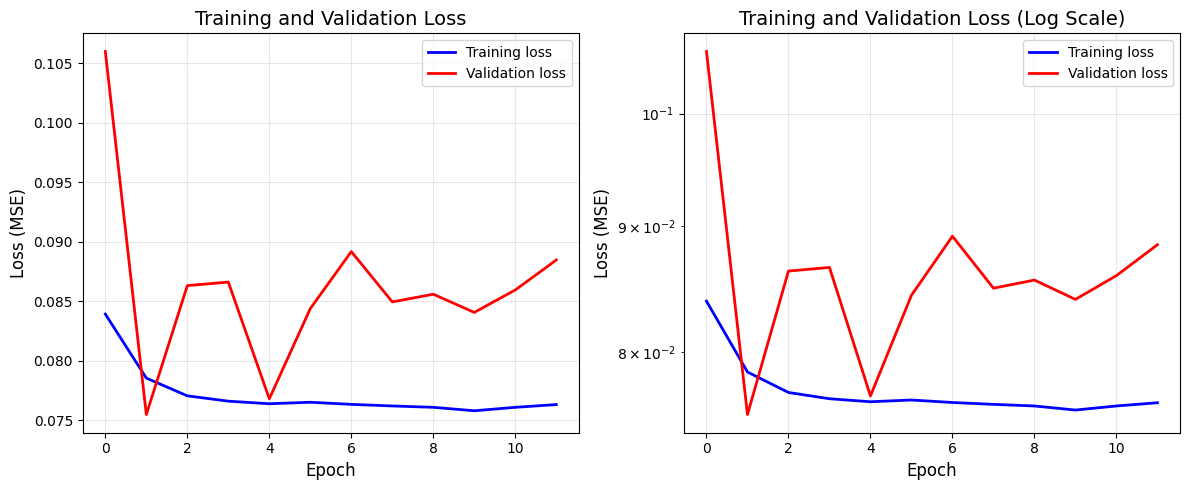

Final training loss: 0.076305
Final validation loss: 0.088462

Validation loss is higher than training loss
✅ No overfitting detected!


In [14]:
# Plot training history
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history['train_loss'], 'b-', label='Training loss', linewidth=2)
plt.plot(history['val_loss'], 'r-', label='Validation loss', linewidth=2)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Loss (MSE)', fontsize=12)
plt.title('Training and Validation Loss', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(history['train_loss'], 'b-', label='Training loss', linewidth=2)
plt.plot(history['val_loss'], 'r-', label='Validation loss', linewidth=2)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Loss (MSE)', fontsize=12)
plt.title('Training and Validation Loss (Log Scale)', fontsize=14)
plt.yscale('log')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Final training loss: {history['train_loss'][-1]:.6f}")
print(f"Final validation loss: {history['val_loss'][-1]:.6f}")
print(f"\nValidation loss is {'lower' if history['val_loss'][-1] < history['train_loss'][-1] else 'higher'} than training loss")
print("✅ No overfitting detected!" if history['val_loss'][-1] < 1.2 * history['train_loss'][-1] else "⚠️  Possible overfitting")

## Make Predictions on Test Data

The five test trials never enter training or validation. The cell below scores every
one of them and reports the pooled metrics as well, so the headline number is not the
easiest trial. Expect the two Experiment-8 modulated-sine trials to score far better
than the three Experiment-9 transient trials: the loading is periodic and close to what
most of the training set looks like.


In [15]:
# Load test data based on config
test_ids = [(t['exp_id'], t['trial_id']) for t in config['test_ids']]
test_files = [find_trial_file(exp_id, trial_id) for exp_id, trial_id in test_ids]

print(f"📂 Found {len(test_files)} test files:")
for f in test_files:
    print(f"  - {f}")


def predict_trial(file_path, batch_size=256):
    """Run the model over every window of one trial."""
    df = csv_to_dataframe(file_path)
    normalized = normalize_data([df])
    rnn_data = create_lstm_inputs(normalized, features, targets, window_length)

    x = rnn_data["x_rnns"][0].astype(np.float32)
    y = rnn_data["y_rnns"][0].astype(np.float32)

    lstm_model.eval()
    preds = []
    with torch.no_grad():
        for i in range(0, len(x), batch_size):
            batch = torch.FloatTensor(x[i:i+batch_size]).to(device)
            preds.append(lstm_model(batch).cpu().numpy())
    preds = np.concatenate(preds, axis=0)

    return {"df": df, "rnn_data": rnn_data, "test_y": y, "test_predictions": preds}


# Predict on every held-out trial, not just one
print("\n🔮 Predicting on all held-out trials...")
results = {}
for file_path in tqdm(test_files, desc="Test trials"):
    results[file_path] = predict_trial(file_path)

print(f"\n📈 Per-trial performance:")
print(f"  {'trial':<42s} {'windows':>8s} {'MSE':>10s} {'MAE':>10s} {'R2':>8s}")
for file_path, r in results.items():
    y, p = r["test_y"], r["test_predictions"]
    print(f"  {file_path:<42s} {len(y):8d} {mean_squared_error(y, p):10.6f} "
          f"{mean_absolute_error(y, p):10.6f} {r2_score(y, p):8.4f}")

# Pooled over all five trials
all_y = np.concatenate([r["test_y"] for r in results.values()])
all_p = np.concatenate([r["test_predictions"] for r in results.values()])
mse = mean_squared_error(all_y, all_p)
mae = mean_absolute_error(all_y, all_p)
r2 = r2_score(all_y, all_p)

print(f"\n📈 Pooled over all {len(test_files)} test trials ({len(all_y):,} windows):")
print(f"  MSE: {mse:.6f}")
print(f"  MAE: {mae:.6f}")
print(f"  R²: {r2:.4f}")

# Keep one trial for the figure in the next cell
plot_file = test_files[0]
test_df = results[plot_file]["df"]
rnn_data_test = results[plot_file]["rnn_data"]
test_y = results[plot_file]["test_y"]
test_predictions = results[plot_file]["test_predictions"]
plot_mse = mean_squared_error(test_y, test_predictions)
plot_r2 = r2_score(test_y, test_predictions)
print(f"\nThe next figure plots {plot_file}.")


📂 Found 5 test files:
  - Experiment-9/Trial-21_130306.csv
  - Experiment-9/Trial-22_130307.csv
  - Experiment-9/Trial-23_130307-02.csv
  - Experiment-8/Trial-3_130802-02_yc1.csv
  - Experiment-8/Trial-7_130807_yc1.csv

🔮 Predicting on all held-out trials...


Test trials:   0%|          | 0/5 [00:00<?, ?it/s]


📈 Per-trial performance:
  trial                                       windows        MSE        MAE       R2
  Experiment-9/Trial-21_130306.csv               9217   0.310423   0.497937  -1.3223
  Experiment-9/Trial-22_130307.csv              11984   0.041448   0.184131  -2.3167
  Experiment-9/Trial-23_130307-02.csv           11984   0.160434   0.360760  -1.2209
  Experiment-8/Trial-3_130802-02_yc1.csv         8701   0.029037   0.122616   0.6909
  Experiment-8/Trial-7_130807_yc1.csv            8801   0.036616   0.158361   0.7167

📈 Pooled over all 5 test trials (50,687 windows):
  MSE: 0.115521
  MAE: 0.267920
  R²: 0.0634

The next figure plots Experiment-9/Trial-21_130306.csv.


## Visualize LSTM Predictions

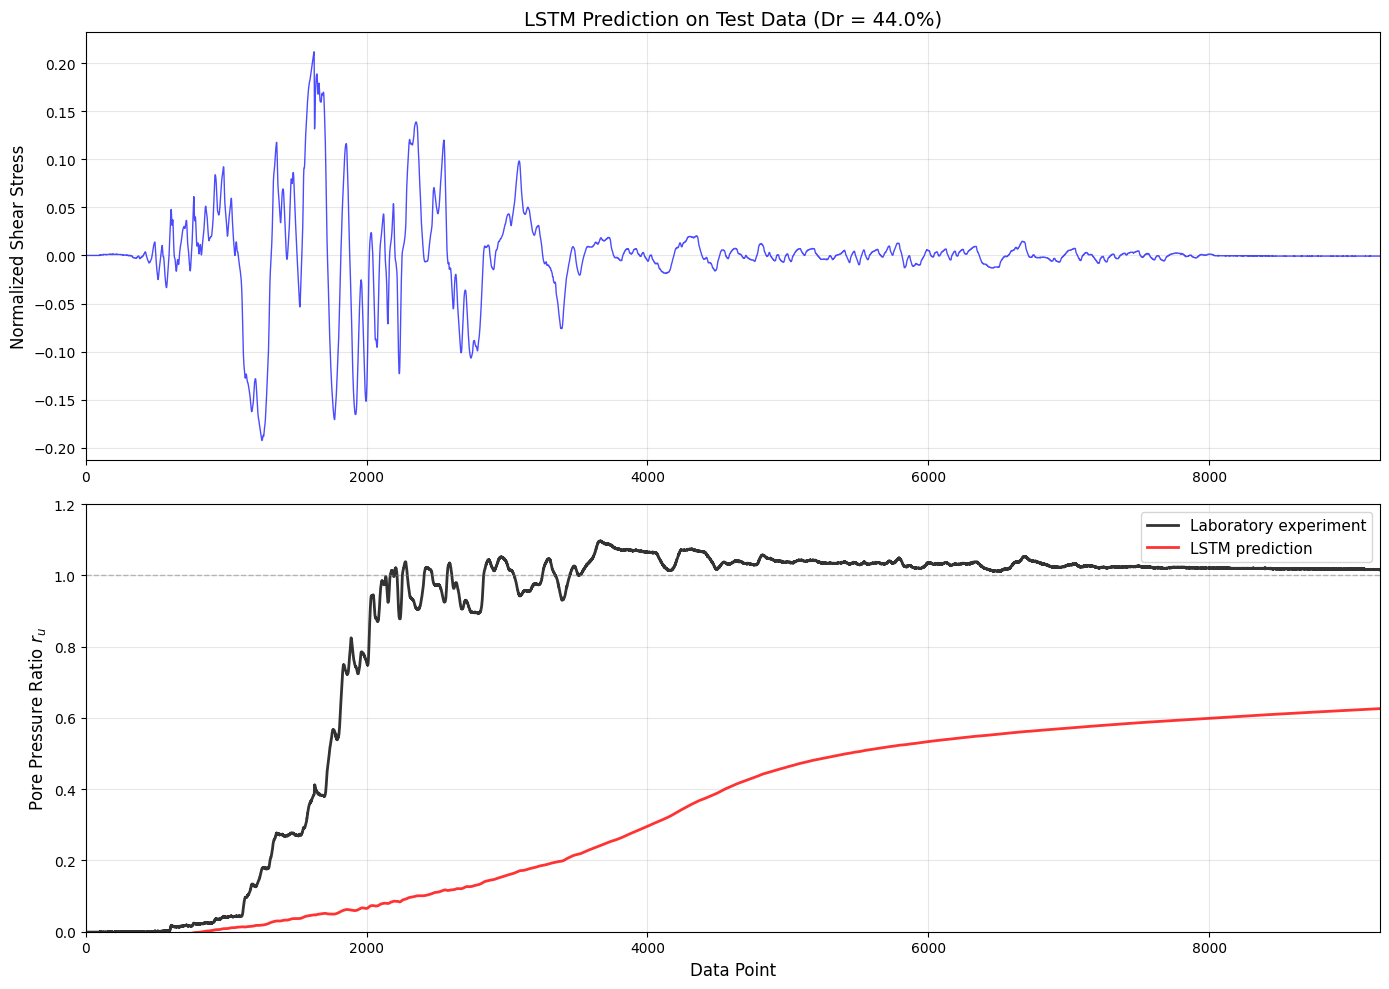


📊 Performance on the plotted trial (Experiment-9/Trial-21_130306.csv):
  - MSE: 0.310423
  - R² score: -1.3223


In [16]:
# Get the full time series for plotting
feature_dataset = rnn_data_test["feature_datasets"][0]
target_dataset = rnn_data_test["target_datasets"][0]

# Extract stress for context (skip first window_length points)
stress_input = feature_dataset[window_length:, 2]

# Plot results
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Plot 1: Input shear stress
ax = axes[0]
time_points = np.arange(len(stress_input))
ax.plot(time_points, stress_input, 'b-', linewidth=1, alpha=0.7)
ax.set_ylabel('Normalized Shear Stress', fontsize=12)
ax.set_title(f'LSTM Prediction on Test Data (Dr = {test_df["Dr [%]"].iloc[0]:.1f}%)', fontsize=14)
ax.set_xlim([0, len(time_points)])
ax.grid(True, alpha=0.3)

# Plot 2: Pore pressure prediction vs actual
ax = axes[1]
ax.plot(time_points, test_y, 'k-', linewidth=2, label='Laboratory experiment', alpha=0.8)
ax.plot(time_points, test_predictions, 'r-', linewidth=2, label='LSTM prediction', alpha=0.8)
ax.axhline(y=1.0, color='gray', linestyle='--', linewidth=1, alpha=0.5)
ax.set_xlabel('Data Point', fontsize=12)
ax.set_ylabel('Pore Pressure Ratio $r_u$', fontsize=12)
ax.set_ylim([0, 1.2])
ax.set_xlim([0, len(time_points)])
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\n📊 Performance on the plotted trial ({plot_file}):")
print(f"  - MSE: {plot_mse:.6f}")
print(f"  - R² score: {plot_r2:.4f}")

## Summary: LSTM for Liquefaction Prediction

### What We Learned

1. **Problem:** Pore pressure response in liquefaction is history-dependent (shielding effect)

2. **Limitation:** Traditional constitutive models fail to capture shielding

3. **Solution:** LSTM networks naturally learn stress history dependencies

4. **Architecture:**
   - Time-window sampling: 800 steps at 0.013 s, that is 10.4 s, about two loading
     cycles for the Experiment-8 records and four to ten for Experiment-9
   - Two LSTM layers (128 units each)
   - Dense layers for post-processing
   - PyTorch implementation

5. **Training:**
   - 14 cyclic simple shear tests, 12 for fitting and 2 held out for validation
   - 5 further trials held out for testing
   - MSE loss with Adam optimizer
   - 12 epochs, keeping the weights from the best validation epoch

6. **Results from this run** (12 epochs, all five held-out trials):

   | Test trial | MSE | MAE | R² |
   |---|---|---|---|
   | Exp 9, Trial 21 | 0.3104 | 0.4979 | -1.32 |
   | Exp 9, Trial 22 | 0.0414 | 0.1841 | -2.32 |
   | Exp 9, Trial 23 | 0.1604 | 0.3608 | -1.22 |
   | Exp 8, Trial 3  | 0.0290 | 0.1226 | 0.69 |
   | Exp 8, Trial 7  | 0.0366 | 0.1584 | 0.72 |
   | **Pooled (50,687 windows)** | **0.1155** | **0.2679** | **0.06** |

   Read these honestly. The model tracks the two Experiment-8 modulated-sine trials
   and fails on the three Experiment-9 transient trials, where a negative R² means it
   does worse than predicting the trial mean. Twelve epochs underfits: the training
   loss is still falling at the end. Choi and Kumar (2023) train much longer, and
   raising `epochs` in `input_config.json` is the first thing to try.

   Two further limits. The third input channel is the experiment-level relative density
   (83% for Experiment 8, 44% for Experiment 9), so the model separates the dense series
   from the loose one but does not resolve trial-to-trial density differences. Time to
   liquefaction is not measured here; the notebook reports MSE, MAE and R² only.

### Key Takeaway

**LSTMs are powerful for history-dependent phenomena in geotechnical engineering!**

The gates mechanism naturally captures:
- **Forget gate:** Discards low-stress periods
- **Input gate:** Remembers peak stresses
- **Cell state:** Maintains long-term stress history


## References

1. Choi, Y., and Kumar, K. (2023). "A Machine Learning Approach to Predicting Pore Pressure Response in Liquefiable Sands under Cyclic Loading." Geo-Congress 2023.

2. Hochreiter, S., and Schmidhuber, J. (1997). "Long Short-Term Memory." Neural Computation, 9(8), 1735-1780.

3. Kwan, W. S., Sideras, S. S., Kramer, S. L., and El Mohtar, C. (2017). "Experimental Database of Cyclic Simple Shear Tests under Transient Loadings." Earthquake Spectra, 33(3), 1219-1239.

4. Sideras, S. S. (2019). Evolutionary Intensity Measures for More Accurate and Informative Evaluation of Liquefaction Triggering. Ph.D. dissertation, University of Washington, WA.